# Imaging, part 6: sparse images and CLEAN

The regularisers of parts 2 and 3 prefer smooth images. Some scenes are not smooth: a companion or two and a few compact knots next to a bright star. **CLEAN** (Högbom 1974), the oldest image reconstruction algorithm in radio astronomy, builds an image for such scenes from point sources, one at a time.

Högbom's CLEAN works on the *dirty image*: it finds the brightest point in the residual dirty image, adds a small fraction (the **loop gain**) of a point source there to the model, subtracts its dirty beam from the residuals, and repeats. That needs data that are linear in the image, such as calibrated complex visibilities. Closure phases, kernel phases, DISCOs and squared visibilities are not linear, so classic CLEAN cannot use them directly.

virgil's `clean` uses the same idea in a form that works for any data. For linear data, the residual dirty image is, up to a constant, minus the gradient of χ² with respect to the flux of a point source at each pixel. JAX computes that gradient for any likelihood. So each iteration of `clean`:
1. computes the gradient of χ² with respect to the flux at every pixel;
2. picks the pixel where a step would lower χ² the most;
3. adds the loop gain times that (Gauss–Newton) step there;
4. stops when χ² per data point reaches one, the discrepancy principle of part 2.

For linear data this is exactly Högbom's CLEAN. Mathematically it is *matching pursuit*. Step 2 normalises the gradient by how strongly each pixel affects the data. Without that, CLEAN would pile flux into pixels right next to the star, whose light is nearly indistinguishable from the star's own (`design/sparse_imaging.md` has the details).

This part reconstructs a companion and a knot from AMI DISCOs, refines the result, looks at the loop gain, and then uses closure phases and V² from a long-baseline interferometer.

In [1]:
import sys
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro.distributions as dist

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from virgil.coverage import ami_grid_record, vlti_oidata
from virgil.fitting import fit
from virgil.imaging import (
    beam,
    clean,
    dirty_image,
    field_of_view,
    image_priors,
)
from virgil.likelihood import whitened_residuals
from virgil.models import Image, PointSource, System, circular_support
from virgil.oidata import OIData
from virgil.plotting import plot_model, plot_residual_map
from virgil.scenes import gaussian_blob

# A star with a 2% companion and a 1% knot, both on pixel centres.
template = OIData(ami_grid_record(wavelength_m=4.8e-6, rotation_deg=-6.9))
npix, scale = 40, 20.0
fov = npix * scale
truth = System(
    star=PointSource(),
    companion=PointSource(dra=-90.0, ddec=70.0, flux=0.02),
    knot=PointSource(dra=130.0, ddec=-110.0, flux=0.01),
)
data = template.with_model(truth, key=jax.random.PRNGKey(4))
resolution = beam(data)
print(
    f"{data.n_independent} DISCO coefficients; beam {resolution.major_mas:.0f} × "
    f"{resolution.minor_mas:.0f} mas; {npix}² pixels of {scale:.0f} mas; "
    f"the truth has χ²/N = {jnp.mean(whitened_residuals(truth, data) ** 2):.3f}"
)

588 DISCO coefficients; beam 154 × 131 mas; 40² pixels of 20 mas; the truth has χ²/N = 0.989


## The dirty image

The truth is shown without the star, which would swamp it. The dirty image (part 2), with the star removed, shows the two sources as blurred peaks surrounded by the sidelobes of the dirty beam. CLEAN's job is to replace those patterns with the point sources that made them.

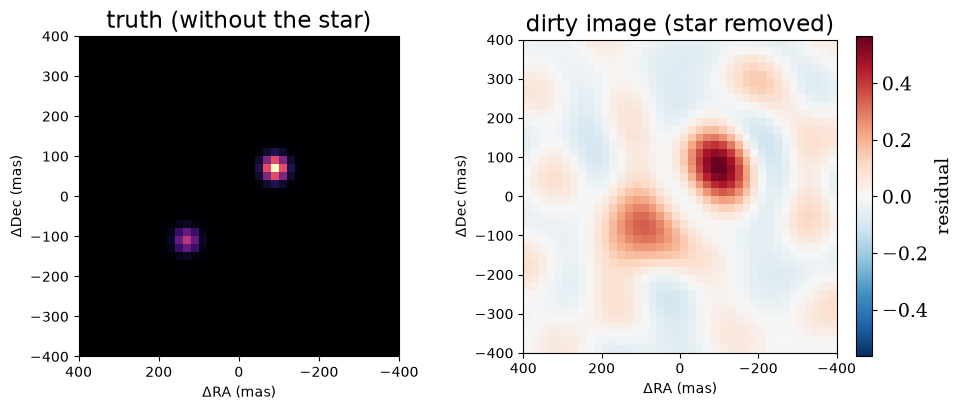

In [2]:
dirty = dirty_image(data, npix, scale, flux_ratio=0.03)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
faint = System(companion=truth.companion, knot=truth.knot)
plot_model(faint, fov_mas=fov, npix=npix, ax=axes[0], title="truth (without the star)")
plot_residual_map(dirty, fov, ax=axes[1], title="dirty image (star removed)")
plt.tight_layout()
plt.show()

## Running CLEAN

`clean(data, npix, pixel_scale_mas, base=...)` adds components to a fixed **base** scene, here the star, with flux 1. Fit the base's parameters first if it has any. The component fluxes are relative to the base, like a companion's flux in a `System`.

The **support** says where components may go. A hole of half a beam under the star stops CLEAN trading the star's flux against the pixels around it, as `starting_image` does in part 2. The loop gain is 0.1 by default, and CLEAN stops when χ² per data point reaches `target_chi2_red`, 1 by default. That target assumes the error bars are right. Even then, noise scatters the truth's own χ² per point around one by about √(2/N); if it lands above the target, CLEAN keeps adding components until `max_iterations`, so check `result.stop`.

The result holds the χ² history, the components on the pixel grid, and `model`, an ordinary virgil model: `System(base=star, clean=Image(...))`, whose Image is non-zero only on the components.

In [3]:
support = circular_support(
    npix, scale, radius_mas=fov / 2, inner_radius_mas=0.5 * resolution.minor_mas
)
result = clean(data, npix, scale, base=PointSource(), support=support)
components = result.components
print(
    f"stopped ({result.stop}) after {len(result.chi2_red) - 1} iterations at "
    f"χ²/N = {float(result.chi2_red[-1]):.3f}: {int((components > 0).sum())} "
    f"components with total flux {float(components.sum()):.4f} (truth 0.030)"
)


def position(index):
    # Pixel (row, column) to (dra, ddec): column 0 is East, row 0 North.
    row, col = jnp.unravel_index(index, components.shape)
    centre = (npix - 1) / 2
    return float((centre - col) * scale), float((centre - row) * scale)


print("brightest components (dra, ddec in mas: flux):")
for index in jnp.argsort(components.ravel())[::-1][:5]:
    dra, ddec = position(index)
    print(f"  ({dra:6.0f}, {ddec:6.0f}): {float(components.ravel()[index]):.4f}")

stopped (target) after 85 iterations at χ²/N = 1.000: 13 components with total flux 0.0297 (truth 0.030)
brightest components (dra, ddec in mas: flux):


  (   -90,     70): 0.0173
  (   130,   -110): 0.0047
  (   110,    -90): 0.0033
  (   150,   -130): 0.0021
  (  -110,     70): 0.0010


χ² per point falls from about 160 to near one in some 60 iterations, then creeps down to the target. The brightest components sit exactly on the companion and the knot (circled), with a few fainter ones on the pixels next to them. The restored image, the components convolved with the beam, is the radio astronomers' way of showing what the data resolve; virgil's `plot_model(..., beam=, convolve=True)` draws it.

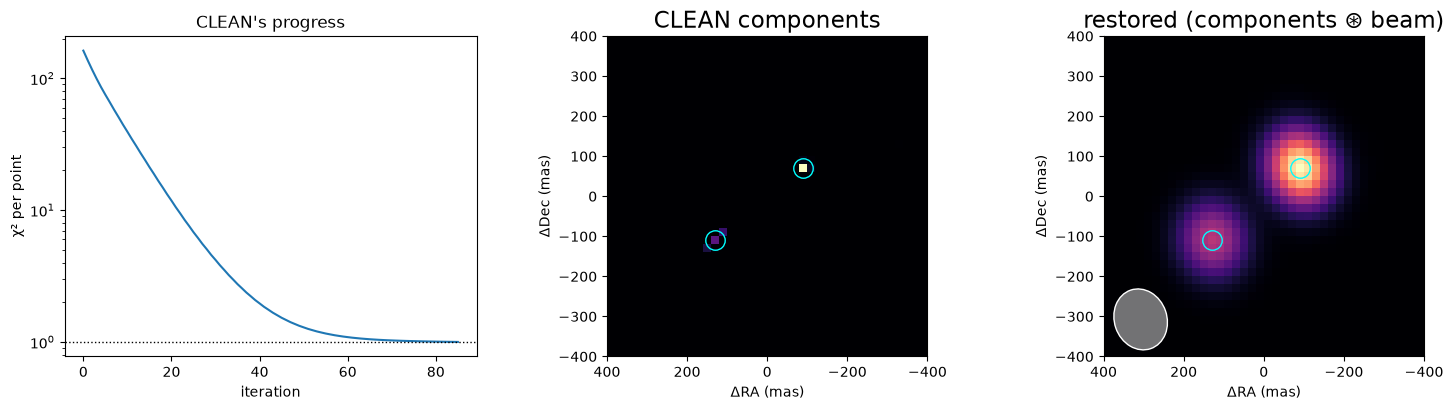

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].semilogy(result.chi2_red)
axes[0].axhline(1.0, color="k", ls=":", lw=1)
axes[0].set(xlabel="iteration", ylabel="χ² per point", title="CLEAN's progress")
plot_model(result.model.clean, fov, npix, ax=axes[1], title="CLEAN components")
plot_model(
    result.model.clean, fov, npix, ax=axes[2], beam=resolution, convolve=True,
    title="restored (components ⊛ beam)",
)
for ax in axes[1:]:
    ax.plot([-90, 130], [70, -110], "o", mfc="none", mec="cyan", ms=14)
plt.tight_layout()
plt.show()

## Refining the fluxes

CLEAN stops as soon as χ² per point reaches one, and each step adds only a fraction of the flux the data ask for, so the total is usually a little low. A source between two pixel centres is also shared between them. Both are easy to fix: the model is a `System` with an `Image`, so `fit` can refit the component fluxes on their support. That is a small, well-posed problem: a few pixels, not the whole grid. It needs no regulariser.

In [5]:
priors = image_priors(result.model) | {"clean.flux": dist.Uniform(0.0, 1.0)}
polished = fit(result.model, priors, data)
print(
    f"flux {float(components.sum()):.4f} after CLEAN, "
    f"{float(polished.model.clean.flux):.4f} refitted (truth 0.030); "
    f"χ²/N {polished.info['chi2_red']:.3f}"
)

flux 0.0297 after CLEAN, 0.0300 refitted (truth 0.030); χ²/N 0.958


## The loop gain

The loop gain trades speed against care. A small gain takes many small steps, and can correct an early step with later ones. A large gain moves quickly, but a step that overshoots cannot be undone, because `clean` only ever adds flux (so the image stays positive). Here a gain of 0.5 gets χ² per point to about 1.1 within twenty iterations and then stalls: its early steps put flux where it cannot be taken back, and it runs to `max_iterations` without reaching the target. Gains of 0.03 and 0.1 both reach it, the smaller one with three times as many iterations. Values of 0.05–0.2 are the usual choice, as in radio astronomy.

gain 0.03: 281 iterations, 12 components, flux 0.0296, stopped (target)


gain 0.1: 85 iterations, 13 components, flux 0.0297, stopped (target)


gain 0.5: 1000 iterations, 22 components, flux 0.0301, stopped (max_iterations)


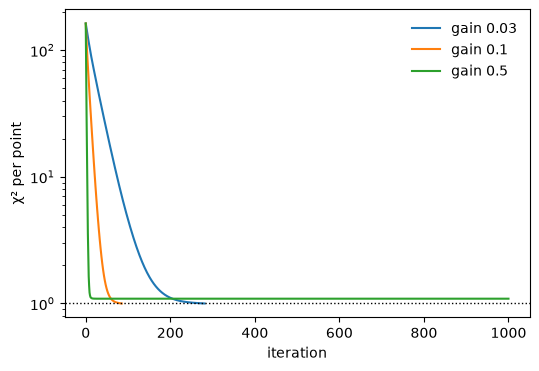

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
for gain in (0.03, 0.1, 0.5):
    run = clean(data, npix, scale, base=PointSource(), support=support, gain=gain)
    print(
        f"gain {gain}: {len(run.chi2_red) - 1} iterations, "
        f"{int((run.components > 0).sum())} components, flux "
        f"{float(run.components.sum()):.4f}, stopped ({run.stop})"
    )
    ax.semilogy(run.chi2_red, label=f"gain {gain}")
ax.axhline(1.0, color="k", ls=":", lw=1)
ax.set(xlabel="iteration", ylabel="χ² per point")
ax.legend(frameon=False)
plt.show()

## Closure phases and V² from a long-baseline interferometer

Classic CLEAN needs Fourier phases; with closure phases it has to be wrapped in self-calibration loops. Gradient CLEAN does not: it fits closure phases and squared visibilities directly, through the same likelihood as `fit`.

Here are four VLTI unit telescopes in the L band, at five hour angles, with a star, a 3% companion and a 4% extended blob. The blob is larger than the beam, so CLEAN builds it from a cluster of components. CLEAN stops at χ² per point of one with about 90% of the true flux; the restored image matches the truth convolved with the beam, including the beam's elongation.

330 V² and 220 closure phases; field 24.1 mas, beam 6.8 × 3.9 mas
stopped (target) after 54 iterations at χ²/N = 0.997: 30 components with flux 0.0623 (truth 0.070)


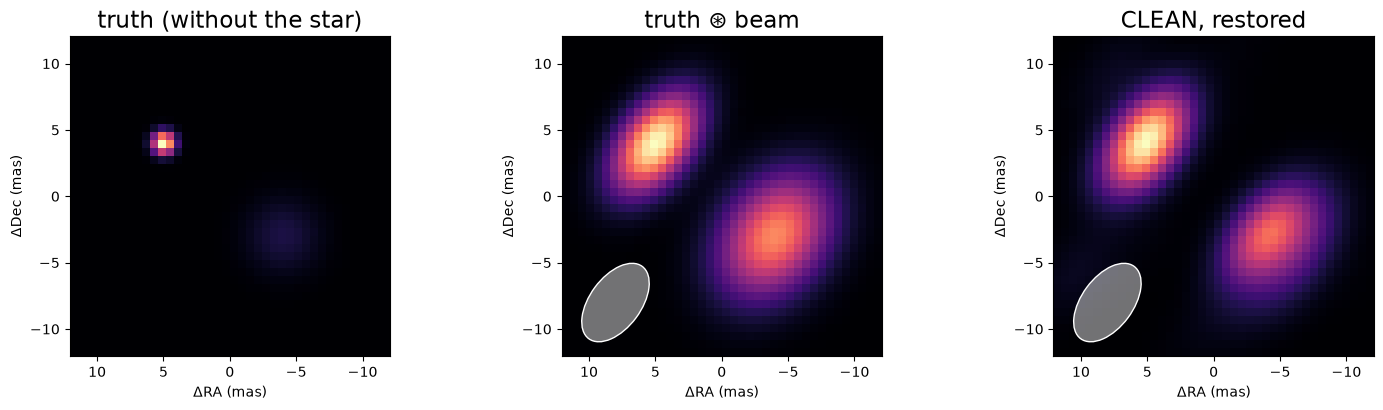

In [7]:
vlti = vlti_oidata()
vfov, vnpix = field_of_view(vlti), 40
vscale = vfov / vnpix
blob = gaussian_blob(vnpix, vscale, 2.0, dra=-4.0, ddec=-3.0)
vtruth = System(
    star=PointSource(),
    companion=PointSource(dra=5.0, ddec=4.0, flux=0.03),
    blob=Image.from_brightness(blob, vscale, flux=0.04),
)
vdata = vlti.with_model(vtruth, key=jax.random.PRNGKey(1))
vbeam = beam(vdata)
vsupport = circular_support(
    vnpix, vscale, radius_mas=vfov / 2, inner_radius_mas=0.5 * vbeam.minor_mas
)
vresult = clean(vdata, vnpix, vscale, base=PointSource(), support=vsupport)
print(
    f"{vdata.vis.size} V² and {vdata.phi.size} closure phases; field "
    f"{vfov:.1f} mas, beam {vbeam.major_mas:.1f} × {vbeam.minor_mas:.1f} mas"
)
print(
    f"stopped ({vresult.stop}) after {len(vresult.chi2_red) - 1} iterations at "
    f"χ²/N = {float(vresult.chi2_red[-1]):.3f}: {int((vresult.components > 0).sum())} "
    f"components with flux {float(vresult.components.sum()):.4f} (truth 0.070)"
)

envelope = System(
    companion=PointSource(dra=5.0, ddec=4.0, flux=0.03),
    blob=Image.from_brightness(blob, vscale, flux=0.04),
)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
plot_model(envelope, vfov, vnpix, ax=axes[0], title="truth (without the star)")
plot_model(
    envelope, vfov, vnpix, ax=axes[1], beam=vbeam, convolve=True,
    title="truth ⊛ beam",
)
plot_model(
    vresult.model.clean, vfov, vnpix, ax=axes[2], beam=vbeam, convolve=True,
    title="CLEAN, restored",
)
plt.tight_layout()
plt.show()

## Summary

- `clean` builds an image from point components where they lower χ² most. It works for any data virgil fits: DISCOs, kernel and closure phases, V², or a mix.
- Give it a fixed `base` (usually the star), a `support` with a hole under the star, and trust its stopping rule only as far as you trust the error bars.
- The result is an ordinary model. Refit its fluxes with `fit` on the components' support, show it restored with the beam, or use it as the starting image of a regularised fit.
- Components are only ever added, so an early mistake stays. Keep the loop gain small. The base scene is fixed, and the components are grey (the same fraction of the base's flux at every wavelength).
- For extended emission, a regularised fit started from the CLEAN image usually does better. `notebooks/mwe/mwe_sparse_imaging.ipynb` compares CLEAN with the sparsity regularisers `StarletL1` and `LogSum` and with maximum entropy, each started from CLEAN.